# EDA: Outlier Analysis - 論文範圍 vs 實際數據

## 目標
驗證論文範圍（23-64歲）是否適用於我們的競賽數據

## 論文參考範圍
來源: [PMC8306797](https://pmc.ncbi.nlm.nih.gov/articles/PMC8306797/)

| 特徵 | 性別 | 下限 | 上限 |
|------|------|------|------|
| Weight | 男 | 61.7 kg | 82.7 kg |
| Weight | 女 | 48.6 kg | 66.2 kg |
| Height | 男 | 164.4 cm | 178.0 cm |
| Height | 女 | 152.6 cm | 164.2 cm |

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 設定繁體中文字體
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 設定顯示風格
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. 載入數據

In [13]:
# 讀取訓練數據
df = pd.read_csv('../dataset/train.csv')

# 建立 gender mapping: 1=男, 2=女
GENDER_MAPPING = {1: '男', 2: '女'}
df['gender_label'] = df['gender'].map(GENDER_MAPPING)

print(f"總樣本數: {len(df)}")
print(f"\nGender 分布（原始數據）:")
print(df['gender'].value_counts())
print(f"\nGender 分布（標籤）:")
print(df['gender_label'].value_counts())
print(f"\n前 5 筆數據:")
df.head()

總樣本數: 423

Gender 分布（原始數據）:
gender
1    316
2    107
Name: count, dtype: int64

Gender 分布（標籤）:
gender_label
男    316
女    107
Name: count, dtype: int64

前 5 筆數據:


,id,gender,star_sign,phone_os,height,weight,sleepiness,iq,fb_friends,yt,self_intro,gender_label
0,1,2,處女座,Apple,154.0,43.0,NaN,NaN,583.0,0,Beautiful,女
1,2,2,處女座,Apple,156.0,47.0,NaN,130.0,NaN,3.5,Enjoying being who I'm notsss,女
2,3,1,射手座,NaN,170.0,61.0,NaN,90.0,540.0,NaN,Practice Makes perfect,男
3,4,1,射手座,Apple,170.0,62.0,4.0,100.0,NaN,5,Straightforward,男
4,5,2,射手座,Android,158.0,67.0,NaN,128.0,320.0,1.2,Humorous,女


## 2. 基本統計資訊

In [14]:
# 缺失值統計
print("=" * 60)
print("缺失值統計")
print("=" * 60)
missing_stats = df[['gender', 'height', 'weight', 'star_sign', 'sleepiness', 'phone_os']].isnull().sum()
missing_pct = (missing_stats / len(df) * 100).round(2)
pd.DataFrame({
    '缺失數量': missing_stats,
    '缺失比例(%)': missing_pct
})

缺失值統計


,缺失數量,缺失比例(%)
gender,0,0.00
height,74,17.49
weight,85,20.09
star_sign,86,20.33
sleepiness,91,21.51
phone_os,78,18.44


In [15]:
# 性別分布
print("\n" + "=" * 60)
print("性別分布")
print("=" * 60)
gender_counts = df['gender_label'].value_counts()
print(gender_counts)
print(f"\n男女比例 (男/女): {gender_counts.get('男', 0) / gender_counts.get('女', 1):.2f}")


性別分布
gender_label
男    316
女    107
Name: count, dtype: int64

男女比例 (男/女): 2.95


## 3. Weight & Height 描述性統計

In [16]:
# 全局統計
print("=" * 60)
print("Weight & Height 全局統計（忽略缺失值）")
print("=" * 60)
df[['weight', 'height']].describe()

Weight & Height 全局統計（忽略缺失值）


,weight,height
count,3.380000e+02,3.490000e+02
mean,2.958580e+108,2.865330e+108
std,5.439283e+109,5.352877e+109
min,-1.000000e+03,-1.870000e+02
25%,5.500000e+01,1.650000e+02
50%,6.450000e+01,1.710000e+02
75%,7.275000e+01,1.760000e+02
max,1.000000e+111,1.000000e+111


In [17]:
# 分性別統計
print("\n" + "=" * 60)
print("依性別分組的 Weight & Height 統計")
print("=" * 60)

stats_summary = []

for gender_label in ['男', '女']:
    subset = df[df['gender_label'] == gender_label]
    
    weight_stats = subset['weight'].describe()
    height_stats = subset['height'].describe()
    
    print(f"\n{'='*40}")
    print(f"{gender_label} (樣本數: {len(subset)})")
    print(f"{'='*40}")
    print(f"\nWeight:")
    print(f"  Mean: {weight_stats['mean']:.2f} kg")
    print(f"  Std:  {weight_stats['std']:.2f} kg")
    print(f"  Min:  {weight_stats['min']:.2f} kg")
    print(f"  Max:  {weight_stats['max']:.2f} kg")
    print(f"  1%:   {subset['weight'].quantile(0.01):.2f} kg")
    print(f"  99%:  {subset['weight'].quantile(0.99):.2f} kg")
    print(f"  Missing: {subset['weight'].isnull().sum()} ({subset['weight'].isnull().sum()/len(subset)*100:.1f}%)")
    
    print(f"\nHeight:")
    print(f"  Mean: {height_stats['mean']:.2f} cm")
    print(f"  Std:  {height_stats['std']:.2f} cm")
    print(f"  Min:  {height_stats['min']:.2f} cm")
    print(f"  Max:  {height_stats['max']:.2f} cm")
    print(f"  1%:   {subset['height'].quantile(0.01):.2f} cm")
    print(f"  99%:  {subset['height'].quantile(0.99):.2f} cm")
    print(f"  Missing: {subset['height'].isnull().sum()} ({subset['height'].isnull().sum()/len(subset)*100:.1f}%)")
    
    stats_summary.append({
        'gender': gender_label,
        'weight_min': weight_stats['min'],
        'weight_max': weight_stats['max'],
        'weight_1pct': subset['weight'].quantile(0.01),
        'weight_99pct': subset['weight'].quantile(0.99),
        'height_min': height_stats['min'],
        'height_max': height_stats['max'],
        'height_1pct': subset['height'].quantile(0.01),
        'height_99pct': subset['height'].quantile(0.99)
    })

stats_df = pd.DataFrame(stats_summary)
stats_df


依性別分組的 Weight & Height 統計

男 (樣本數: 316)

Weight:
  Mean: 3875968992248061993668293633484741474825951186124172660062254448346587516846714149821314140252924381461741568.00 kg
  Std:  62257280636469038837293338332694727687115369416997965074777792531827266018215483724179811585305739797179924480.00 kg
  Min:  -1000.00 kg
  Max:  999999999999999956819772641641815758405104477258378281795396215622882607621111488153942930947432322044748890112.00 kg
  1%:   11.14 kg
  99%:  183.01 kg
  Missing: 58 (18.4%)

Height:
  Mean: 3787878787878787715226411521370514236382971504766584400740137180389706847049664727855844435406940613805867008.00 cm
  Std:  61545745489666365987116519356794575085294046430762080110490573994072928124042779577911569613324568036162666496.00 cm
  Min:  -187.00 cm
  Max:  999999999999999956819772641641815758405104477258378281795396215622882607621111488153942930947432322044748890112.00 cm
  1%:   65.91 cm
  99%:  203.70 cm
  Missing: 52 (16.5%)

女 (樣本數: 107)

Weight:
  Mean: 59.40 k

,gender,weight_min,weight_max,weight_1pct,weight_99pct,height_min,height_max,height_1pct,height_99pct
0,男,-1000.0,1.000000e+111,11.14,183.01,-187.0,1.000000e+111,65.91,203.7
1,女,10.0,5.000000e+02,36.07,168.20,147.0,9.000000e+02,149.52,295.2


## 4. 論文範圍 vs 實際數據範圍對比

In [18]:
# 定義論文範圍
PAPER_RANGES = {
    '男': {
        'weight': (61.7, 82.7),
        'height': (164.4, 178.0)
    },
    '女': {
        'weight': (48.6, 66.2),
        'height': (152.6, 164.2)
    }
}

# 建立對比表
print("\n" + "=" * 80)
print("論文範圍 vs 實際數據範圍 vs 1%-99% Percentile")
print("=" * 80)

comparison_data = []

for gender_label in ['男', '女']:
    subset = df[df['gender_label'] == gender_label]
    
    for feature in ['weight', 'height']:
        paper_min, paper_max = PAPER_RANGES[gender_label][feature]
        actual_min = subset[feature].min()
        actual_max = subset[feature].max()
        pct_1 = subset[feature].quantile(0.01)
        pct_99 = subset[feature].quantile(0.99)
        
        comparison_data.append({
            '性別': gender_label,
            '特徵': feature,
            '論文下限': paper_min,
            '實際最小值': f"{actual_min:.2f}",
            '1% Percentile': f"{pct_1:.2f}",
            '99% Percentile': f"{pct_99:.2f}",
            '實際最大值': f"{actual_max:.2f}",
            '論文上限': paper_max
        })

comparison_df = pd.DataFrame(comparison_data)
comparison_df


論文範圍 vs 實際數據範圍 vs 1%-99% Percentile


,性別,特徵,論文下限,實際最小值,1% Percentile,99% Percentile,實際最大值,論文上限
0,男,weight,61.7,-1000.00,11.14,183.01,9999999999999999568197726416418157584051044772...,82.7
1,男,height,164.4,-187.00,65.91,203.70,9999999999999999568197726416418157584051044772...,178.0
2,女,weight,48.6,10.00,36.07,168.20,500.00,66.2
3,女,height,152.6,147.00,149.52,295.20,900.00,164.2


## 5. 計算裁剪影響：有多少樣本會被論文範圍裁掉？

In [19]:
print("\n" + "=" * 80)
print("如果使用論文範圍裁剪，會影響多少樣本？")
print("=" * 80)

clipping_impact = []

for gender_label in ['男', '女']:
    subset = df[df['gender_label'] == gender_label].copy()
    total_samples = len(subset)
    
    for feature in ['weight', 'height']:
        paper_min, paper_max = PAPER_RANGES[gender_label][feature]
        
        # 計算有效樣本（非缺失值）
        valid_samples = subset[feature].notna().sum()
        
        # 計算會被裁剪的樣本數
        below_min = (subset[feature] < paper_min).sum()
        above_max = (subset[feature] > paper_max).sum()
        total_clipped = below_min + above_max
        
        clipping_pct = (total_clipped / valid_samples * 100) if valid_samples > 0 else 0
        
        clipping_impact.append({
            '性別': gender_label,
            '特徵': feature,
            '有效樣本數': valid_samples,
            '低於論文下限': below_min,
            '高於論文上限': above_max,
            '總裁剪數': total_clipped,
            '裁剪比例(%)': f"{clipping_pct:.2f}%"
        })
        
        print(f"\n{gender_label} - {feature}:")
        print(f"  有效樣本: {valid_samples}")
        print(f"  低於 {paper_min}: {below_min} 筆")
        print(f"  高於 {paper_max}: {above_max} 筆")
        print(f"  總裁剪: {total_clipped} 筆 ({clipping_pct:.2f}%)")

clipping_df = pd.DataFrame(clipping_impact)
print("\n" + "=" * 80)
clipping_df


如果使用論文範圍裁剪，會影響多少樣本？

男 - weight:
  有效樣本: 258
  低於 61.7: 77 筆
  高於 82.7: 28 筆
  總裁剪: 105 筆 (40.70%)

男 - height:
  有效樣本: 264
  低於 164.4: 19 筆
  高於 178.0: 58 筆
  總裁剪: 77 筆 (29.17%)

女 - weight:
  有效樣本: 80
  低於 48.6: 20 筆
  高於 66.2: 10 筆
  總裁剪: 30 筆 (37.50%)

女 - height:
  有效樣本: 85
  低於 152.6: 5 筆
  高於 164.2: 25 筆
  總裁剪: 30 筆 (35.29%)



,性別,特徵,有效樣本數,低於論文下限,高於論文上限,總裁剪數,裁剪比例(%)
0,男,weight,258,77,28,105,40.70%
1,男,height,264,19,58,77,29.17%
2,女,weight,80,20,10,30,37.50%
3,女,height,85,5,25,30,35.29%


## 6. 視覺化分析

/tmp/ipykernel_15217/1929808557.py:45: UserWarning: Glyph 30007 (\N{CJK UNIFIED IDEOGRAPH-7537}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15217/1929808557.py:45: UserWarning: Glyph 22899 (\N{CJK UNIFIED IDEOGRAPH-5973}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15217/1929808557.py:46: UserWarning: Glyph 30007 (\N{CJK UNIFIED IDEOGRAPH-7537}) missing from font(s) DejaVu Sans.
  plt.savefig('../result/outlier_distribution_analysis.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_15217/1929808557.py:46: UserWarning: Glyph 22899 (\N{CJK UNIFIED IDEOGRAPH-5973}) missing from font(s) DejaVu Sans.
  plt.savefig('../result/outlier_distribution_analysis.png', dpi=150, bbox_inches='tight')
/home/thanatos/miniconda3/envs/boygirl/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30007 (\N{CJK UNIFIED IDEOGRAPH-7537}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/thanatos/min

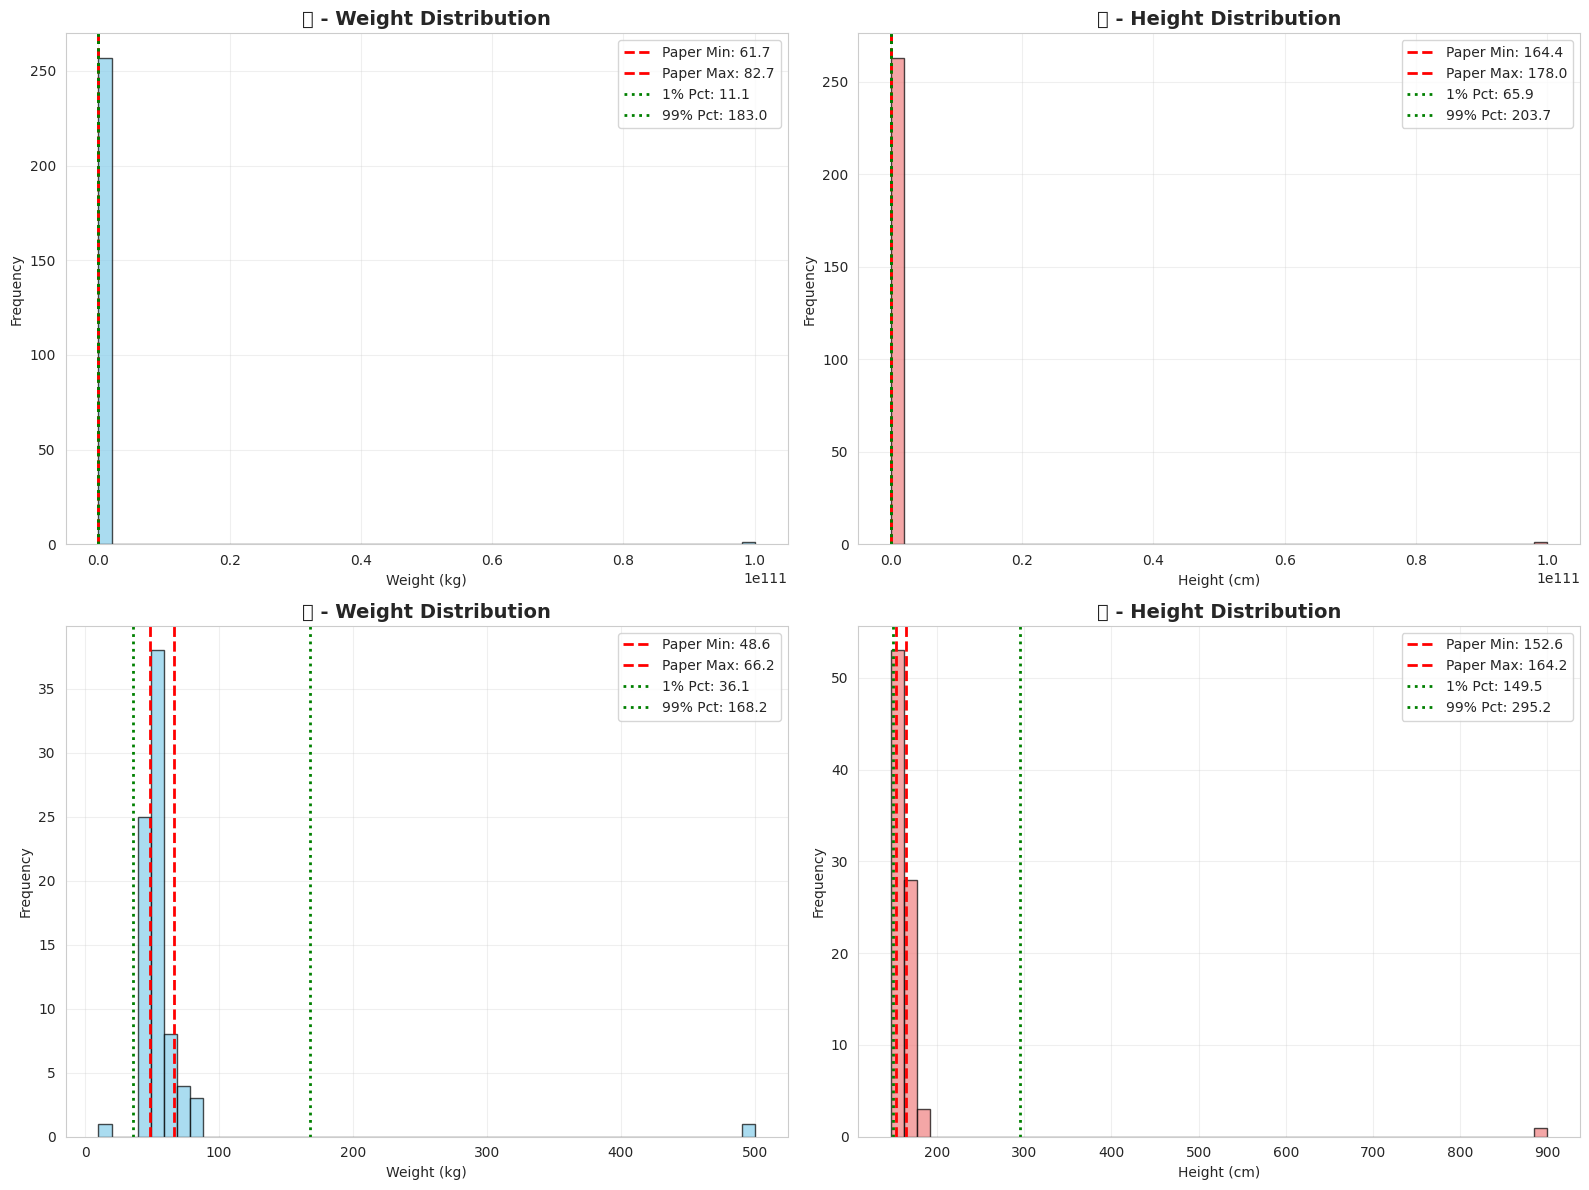


圖表已儲存至: result/outlier_distribution_analysis.png


In [ ]:
# # 6.1 分布直方圖 + 論文範圍標記
# fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# for idx, gender_label in enumerate(['男', '女']):
#     subset = df[df['gender_label'] == gender_label]
    
#     # Weight
#     ax = axes[idx, 0]
#     subset['weight'].dropna().hist(bins=50, ax=ax, alpha=0.7, color='skyblue', edgecolor='black')
    
#     paper_min, paper_max = PAPER_RANGES[gender_label]['weight']
#     ax.axvline(paper_min, color='red', linestyle='--', linewidth=2, label=f'Paper Min: {paper_min}')
#     ax.axvline(paper_max, color='red', linestyle='--', linewidth=2, label=f'Paper Max: {paper_max}')
    
#     pct_1 = subset['weight'].quantile(0.01)
#     pct_99 = subset['weight'].quantile(0.99)
#     ax.axvline(pct_1, color='green', linestyle=':', linewidth=2, label=f'1% Pct: {pct_1:.1f}')
#     ax.axvline(pct_99, color='green', linestyle=':', linewidth=2, label=f'99% Pct: {pct_99:.1f}')
    
#     ax.set_title(f'{gender_label} - Weight Distribution', fontsize=14, fontweight='bold')
#     ax.set_xlabel('Weight (kg)')
#     ax.set_ylabel('Frequency')
#     ax.legend()
#     ax.grid(alpha=0.3)
    
#     # Height
#     ax = axes[idx, 1]
#     subset['height'].dropna().hist(bins=50, ax=ax, alpha=0.7, color='lightcoral', edgecolor='black')
    
#     paper_min, paper_max = PAPER_RANGES[gender_label]['height']
#     ax.axvline(paper_min, color='red', linestyle='--', linewidth=2, label=f'Paper Min: {paper_min}')
#     ax.axvline(paper_max, color='red', linestyle='--', linewidth=2, label=f'Paper Max: {paper_max}')
    
#     pct_1 = subset['height'].quantile(0.01)
#     pct_99 = subset['height'].quantile(0.99)
#     ax.axvline(pct_1, color='green', linestyle=':', linewidth=2, label=f'1% Pct: {pct_1:.1f}')
#     ax.axvline(pct_99, color='green', linestyle=':', linewidth=2, label=f'99% Pct: {pct_99:.1f}')
    
#     ax.set_title(f'{gender_label} - Height Distribution', fontsize=14, fontweight='bold')
#     ax.set_xlabel('Height (cm)')
#     ax.set_ylabel('Frequency')
#     ax.legend()
#     ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig('../result/outlier_distribution_analysis.png', dpi=150, bbox_inches='tight')
# plt.show()

# print("\n圖表已儲存至: result/outlier_distribution_analysis.png")

/tmp/ipykernel_15217/1341477392.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='gender_label', y='weight', ax=ax, palette='Set2')
/tmp/ipykernel_15217/1341477392.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='gender_label', y='height', ax=ax, palette='Set2')
/tmp/ipykernel_15217/1341477392.py:35: UserWarning: Glyph 22899 (\N{CJK UNIFIED IDEOGRAPH-5973}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15217/1341477392.py:35: UserWarning: Glyph 30007 (\N{CJK UNIFIED IDEOGRAPH-7537}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15217/1341477392.py:36: UserWarning: Glyph 22899 (\N{CJK UNIFIED IDEOGRAPH-5

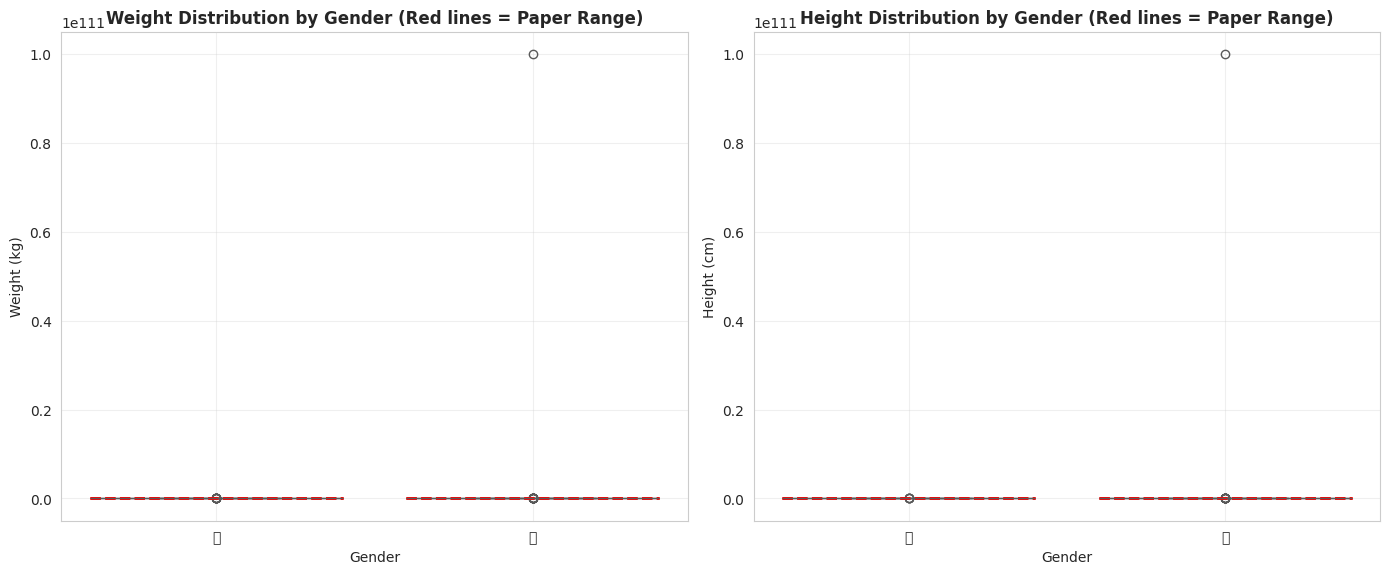


圖表已儲存至: result/outlier_boxplot_analysis.png


In [ ]:
# # 6.2 箱型圖比較
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# # Weight Box Plot
# ax = axes[0]
# df_plot = df[df['gender_label'].isin(['男', '女'])]
# sns.boxplot(data=df_plot, x='gender_label', y='weight', ax=ax, palette='Set2')

# # 添加論文範圍
# for i, gender_label in enumerate(['男', '女']):
#     paper_min, paper_max = PAPER_RANGES[gender_label]['weight']
#     ax.hlines(paper_min, i - 0.4, i + 0.4, colors='red', linestyles='--', linewidth=2)
#     ax.hlines(paper_max, i - 0.4, i + 0.4, colors='red', linestyles='--', linewidth=2)

# ax.set_title('Weight Distribution by Gender (Red lines = Paper Range)', fontsize=12, fontweight='bold')
# ax.set_ylabel('Weight (kg)')
# ax.set_xlabel('Gender')
# ax.grid(alpha=0.3)

# # Height Box Plot
# ax = axes[1]
# sns.boxplot(data=df_plot, x='gender_label', y='height', ax=ax, palette='Set2')

# # 添加論文範圍
# for i, gender_label in enumerate(['男', '女']):
#     paper_min, paper_max = PAPER_RANGES[gender_label]['height']
#     ax.hlines(paper_min, i - 0.4, i + 0.4, colors='red', linestyles='--', linewidth=2)
#     ax.hlines(paper_max, i - 0.4, i + 0.4, colors='red', linestyles='--', linewidth=2)

# ax.set_title('Height Distribution by Gender (Red lines = Paper Range)', fontsize=12, fontweight='bold')
# ax.set_ylabel('Height (cm)')
# ax.set_xlabel('Gender')
# ax.grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig('../result/outlier_boxplot_analysis.png', dpi=150, bbox_inches='tight')
# plt.show()

# print("\n圖表已儲存至: result/outlier_boxplot_analysis.png")

## 7. 結論與建議

In [22]:
print("\n" + "=" * 80)
print("分析結論")
print("=" * 80)

# 判斷論文範圍是否適用
total_clipped_pct = clipping_df['總裁剪數'].sum() / clipping_df['有效樣本數'].sum() * 100

print(f"\n1. 整體裁剪比例: {total_clipped_pct:.2f}%")

if total_clipped_pct < 5:
    print("   ✅ 建議：可以使用論文範圍 (裁剪比例 < 5%)")
    print("   理由：論文範圍與實際數據分布接近，可作為生理學界限使用")
elif total_clipped_pct < 10:
    print("   ⚠️  建議：謹慎使用論文範圍 (裁剪比例 5-10%)")
    print("   理由：會裁剪掉一定數量的樣本，建議進一步檢查被裁剪樣本的特徵")
else:
    print("   ❌ 建議：不建議使用論文範圍 (裁剪比例 > 10%)")
    print("   理由：論文範圍可能不適用於此競賽數據（年齡層、人種差異）")
    print("   替代方案：使用 1%-99% percentile 或更寬鬆的範圍")

print("\n2. 各特徵詳細分析:")
for _, row in clipping_df.iterrows():
    print(f"   {row['性別']} - {row['特徵']}: 裁剪 {row['裁剪比例(%)']}")

print("\n3. 建議的實驗策略:")
if total_clipped_pct < 5:
    print("   - 可以固定使用論文範圍作為 outlier 處理")
    print("   - 實驗重點放在比較不同的補值策略")
else:
    print("   - 階段一：先比較不同 outlier 處理方式（1%-99% vs 論文範圍 vs 不處理）")
    print("   - 階段二：在最佳 outlier 方法下比較補值策略")

print("\n" + "=" * 80)


分析結論

1. 整體裁剪比例: 35.23%
   ❌ 建議：不建議使用論文範圍 (裁剪比例 > 10%)
   理由：論文範圍可能不適用於此競賽數據（年齡層、人種差異）
   替代方案：使用 1%-99% percentile 或更寬鬆的範圍

2. 各特徵詳細分析:
   男 - weight: 裁剪 40.70%
   男 - height: 裁剪 29.17%
   女 - weight: 裁剪 37.50%
   女 - height: 裁剪 35.29%

3. 建議的實驗策略:
   - 階段一：先比較不同 outlier 處理方式（1%-99% vs 論文範圍 vs 不處理）
   - 階段二：在最佳 outlier 方法下比較補值策略



## 8. 查看被論文範圍裁剪的樣本

In [23]:
# 顯示會被論文範圍裁剪掉的樣本
print("\n" + "=" * 80)
print("被論文範圍裁剪的樣本範例")
print("=" * 80)

for gender_label in ['男', '女']:
    subset = df[df['gender_label'] == gender_label].copy()
    
    print(f"\n{'='*40}")
    print(f"{gender_label}")
    print(f"{'='*40}")
    
    for feature in ['weight', 'height']:
        paper_min, paper_max = PAPER_RANGES[gender_label][feature]
        
        outliers = subset[
            (subset[feature] < paper_min) | (subset[feature] > paper_max)
        ][['id', 'gender', 'gender_label', 'weight', 'height', 'star_sign', 'phone_os']]
        
        if len(outliers) > 0:
            print(f"\n{feature} 超出範圍的樣本 ({paper_min} - {paper_max}):")
            print(outliers.head(10))
        else:
            print(f"\n{feature}: 無超出範圍的樣本")


被論文範圍裁剪的樣本範例

男

weight 超出範圍的樣本 (61.7 - 82.7):
    id  gender gender_label  weight  height star_sign phone_os
2    3       1            男    61.0   170.0       射手座      NaN
6    7       1            男    50.0     NaN       NaN  Android
13  14       1            男    53.0     NaN       水瓶座  Android
17  18       1            男    61.0   170.0       射手座      NaN
21  22       1            男    50.0   165.0       天秤座  Android
28  29       1            男    53.0   168.0       水瓶座  Android
33  34       1            男    60.0     NaN       摩羯座  Android
34  35       1            男    55.0     NaN       摩羯座    Apple
35  36       1            男    43.0   162.0       摩羯座    Apple
36  37       1            男   180.0   100.0       摩羯座    Apple

height 超出範圍的樣本 (164.4 - 178.0):
    id  gender gender_label  weight  height star_sign phone_os
35  36       1            男    43.0   162.0       摩羯座    Apple
36  37       1            男   180.0   100.0       摩羯座    Apple
52  53       1            男    65.0  